In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

ROOT = "/content/drive/MyDrive/ML_MED/Prac2/Practical_2/"
TRAIN_IMG_DIR = os.path.join(ROOT, "training_set")
TRAIN_CSV = os.path.join(ROOT, "training_set_pixel_size_and_HC.csv")

df = pd.read_csv(TRAIN_CSV)
df["image_path"] = df["filename"].apply(lambda x: os.path.join(TRAIN_IMG_DIR, x))

df.head()


,filename,pixel size(mm),head circumference (mm),image_path
0,000_HC.png,0.069136,44.30,/content/drive/MyDrive/ML_MED/Prac2/Practical_...
1,001_HC.png,0.089659,56.81,/content/drive/MyDrive/ML_MED/Prac2/Practical_...
2,002_HC.png,0.062033,68.75,/content/drive/MyDrive/ML_MED/Prac2/Practical_...
3,003_HC.png,0.091291,69.00,/content/drive/MyDrive/ML_MED/Prac2/Practical_...
4,004_HC.png,0.061240,59.81,/content/drive/MyDrive/ML_MED/Prac2/Practical_...


In [ ]:
print("Number of training samples:", len(df))
print("HC statistics:")
df["head circumference (mm)"].describe()


Number of training samples: 999
HC statistics:


,head circumference (mm)
count,999.000000
mean,174.383093
std,65.282061
min,44.300000
25%,153.600000
50%,174.060000
75%,189.825000
max,346.400000


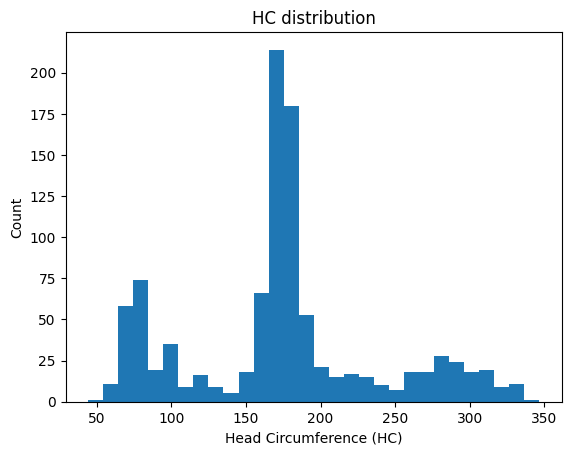

In [ ]:
plt.figure()
plt.hist(df["head circumference (mm)"], bins=30)
plt.xlabel("Head Circumference (HC)")
plt.ylabel("Count")
plt.title("HC distribution")
plt.show()


In [ ]:
heights, widths, channels = [], [], []

for p in df["image_path"].sample(300, random_state=42):
    img = Image.open(p)
    arr = np.array(img)
    if arr.ndim == 2:
        h, w = arr.shape
        c = 1
    else:
        h, w, c = arr.shape
    heights.append(h)
    widths.append(w)
    channels.append(c)

size_df = pd.DataFrame({
    "height": heights,
    "width": widths,
    "channels": channels
})

size_df.describe()


,height,width,channels
count,300.000000,300.000000,300.0
mean,540.046667,799.853333,1.0
std,0.371864,1.261133,0.0
min,540.000000,783.000000,1.0
25%,540.000000,800.000000,1.0
50%,540.000000,800.000000,1.0
75%,540.000000,800.000000,1.0
max,544.000000,800.000000,1.0


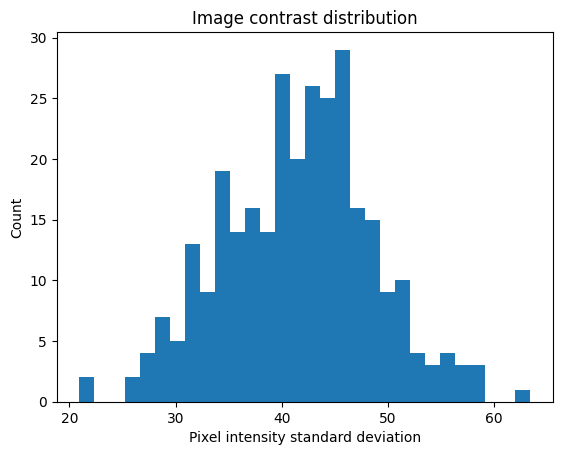

In [ ]:
stds = []

for p in df["image_path"].sample(300, random_state=1):
    img = Image.open(p)
    arr = np.array(img).astype(np.float32)
    stds.append(arr.std())

plt.figure()
plt.hist(stds, bins=30)
plt.xlabel("Pixel intensity standard deviation")
plt.ylabel("Count")
plt.title("Image contrast distribution")
plt.show()


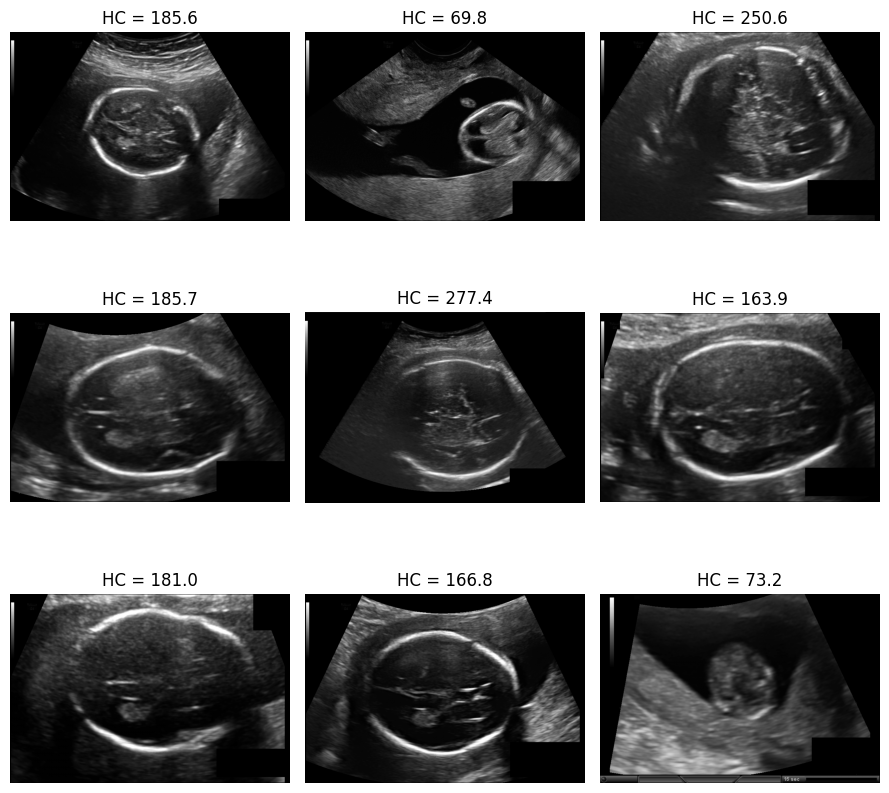

In [ ]:
samples = df.sample(9, random_state=0)

plt.figure(figsize=(9,9))
for i, (_, row) in enumerate(samples.iterrows(), 1):
    img = Image.open(row["image_path"])
    plt.subplot(3,3,i)
    plt.imshow(img, cmap="gray")
    plt.title(f"HC = {row['head circumference (mm)']:.1f}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

IMG_SIZE = 64

def load_image(path):
    img = Image.open(path).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img).flatten() / 255.0

X = np.stack(df["image_path"].apply(load_image).values)
y = df["head circumference (mm)"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error

y_pred = rf.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
mae


27.149677999999998

In [ ]:
results = []

for n in [50, 100, 200]:
    for d in [None, 10, 20]:
        model = RandomForestRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)
        results.append((n, d, mae))

results_df = pd.DataFrame(results, columns=["n_estimators", "max_depth", "MAE"])
results_df


,n_estimators,max_depth,MAE
0,50,NaN,27.492492
1,50,10.0,27.695499
2,50,20.0,27.651893
3,100,NaN,27.149678
4,100,10.0,27.329897
5,100,20.0,27.179859
6,200,NaN,27.134470
7,200,10.0,27.381302
8,200,20.0,27.251256
